# The 'Magic' Methods of the vDataFrame

VerticaPy 0.3.2 introduces the 'Magic' methods, which offer some additional flexilibility for mathematical operations in the vDataFrame. These methods let you handle many operations in a 'pandas-like' or Pythonic style.

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(6,3)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,Abchome.destVarchar(100)
1,1,0,,female,2.0,1,2,113781,151.55,C22 C26,S,[null],[null],"Montreal, PQ / Chesterville, ON"
2,1,0,,male,30.0,1,2,113781,151.55,C22 C26,S,[null],135,"Montreal, PQ / Chesterville, ON"
3,1,0,,female,25.0,1,2,113781,151.55,C22 C26,S,[null],[null],"Montreal, PQ / Chesterville, ON"
4,1,0,,male,39.0,0,0,112050,0.0,A36,S,[null],[null],"Belfast, NI"
5,1,0,,male,71.0,0,0,PC 17609,49.5042,[null],C,[null],22,"Montevideo, Uruguay"
6,1,0,,male,47.0,1,0,PC 17757,227.525,C62 C64,C,[null],124,"New York, NY"
7,1,0,,male,[null],0,0,PC 17318,25.925,[null],S,[null],[null],"New York, NY"
8,1,0,,male,24.0,0,1,PC 17558,247.5208,B58 B60,C,[null],[null],"Montreal, PQ"
9,1,0,,male,36.0,0,0,13050,75.2417,C6,C,A,[null],"Winnipeg, MN"
10,1,0,,male,25.0,0,0,13905,26.0,[null],C,[null],148,"San Francisco, CA"

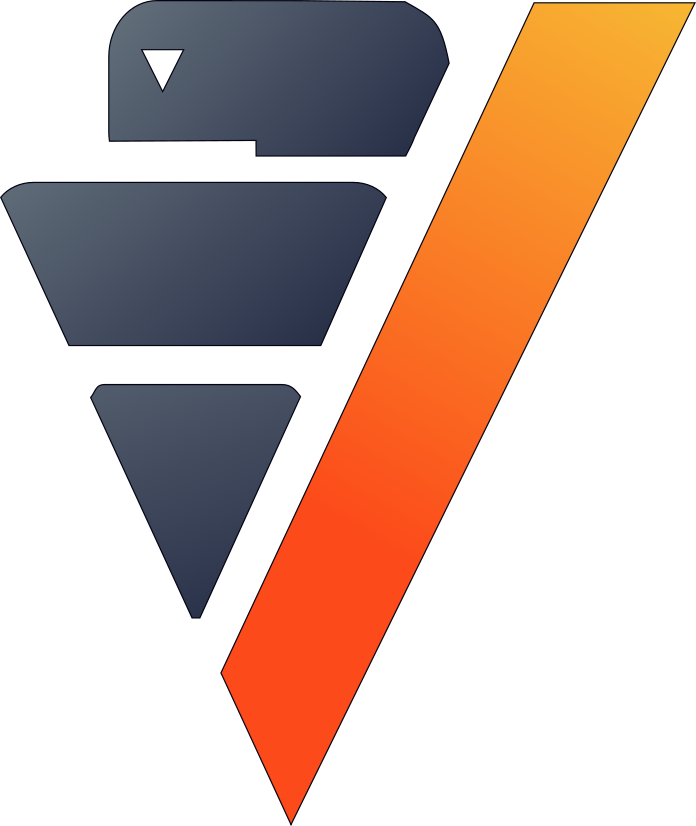

In [11]:
from verticapy.datasets import load_titanic
titanic = load_titanic()
display(titanic)

## Feature Engineering, 'pandas'-style

You can create new features with in a 'pandas' style.

,123sibspInt,123parchInt,123family_sizeInt
1,1,2,4
2,1,2,4
3,1,2,4
4,0,0,1
5,0,0,1
6,1,0,2
7,0,0,1
8,0,1,2
9,0,0,1
10,0,0,1

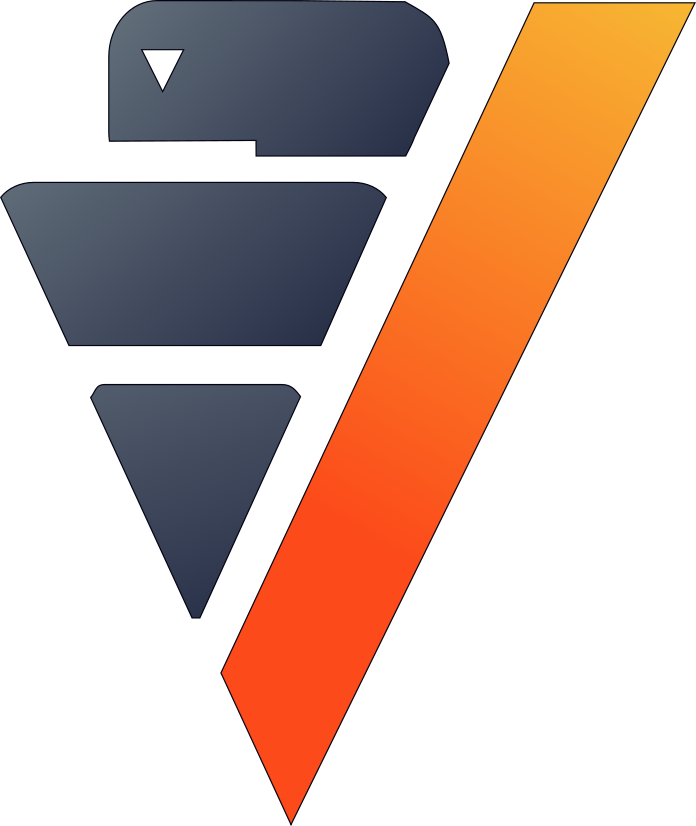

In [12]:
titanic["family_size"] = titanic["parch"] + titanic["sibsp"] + 1
titanic[["sibsp", "parch", "family_size"]]

You can also create features from various mathematical functions.

,"123fareNumeric(10,5)",123ln_fareFloat
1,151.55,5.02091560350381
2,151.55,5.02091560350381
3,151.55,5.02091560350381
4,0.0,-inf
5,49.5042,3.90205751446006
6,227.525,5.42726012246342
7,25.925,3.25520775411559
8,247.5208,5.51149461888159
9,75.2417,4.32070559854228
10,26.0,3.25809653802148

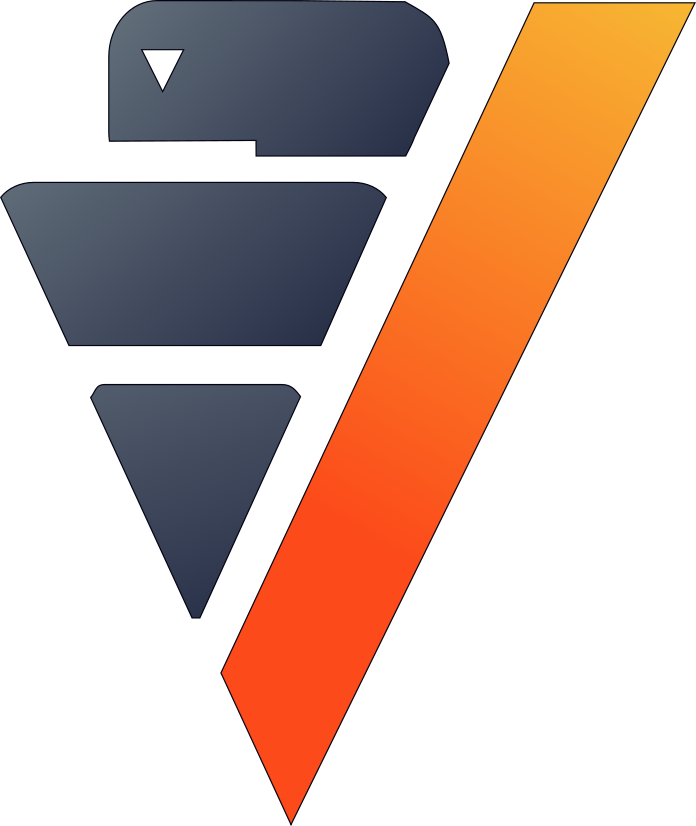

In [3]:
import verticapy.stats as st
titanic["ln_fare"] = st.ln(titanic["fare"])
titanic[["fare", "ln_fare"]]

,"123fareNumeric(10,5)",123xFloat
1,151.55,1.0
2,151.55,1.0
3,151.55,1.0
4,0.0,0.0
5,49.5042,1.0
6,227.525,1.0
7,25.925,0.999999999994493
8,247.5208,1.0
9,75.2417,1.0
10,26.0,0.999999999994891

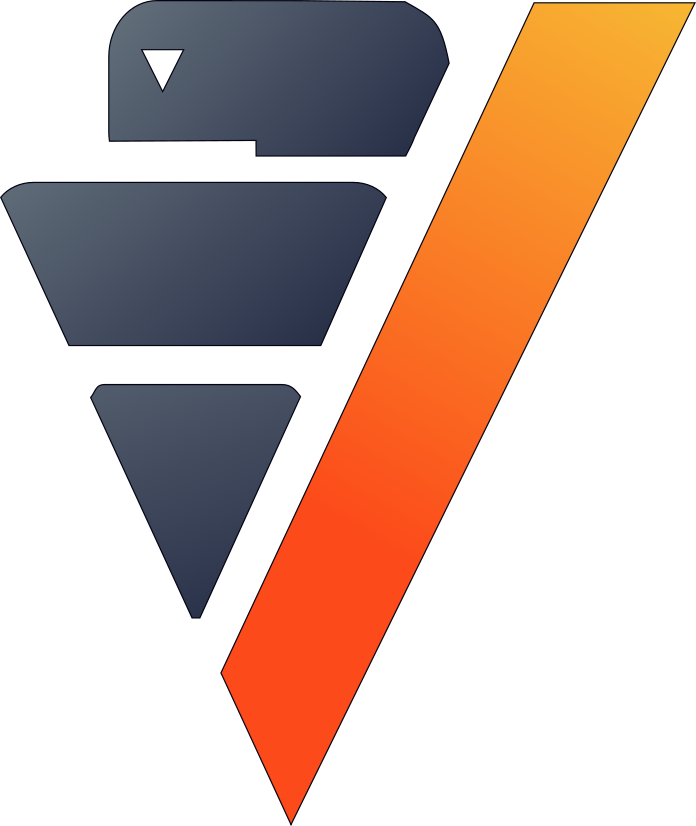

In [4]:
titanic["x"] = 1 - st.exp(-titanic["fare"])
titanic[["fare", "x"]]

## Conditional Operators

You can now filter your data with conditional operators like and ('&'), or ('|'), equals ('=='), not equals (!=), and more!

<b>Equal Operator (==)</b>

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(6,3)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,AbcVarchar(100),123family_sizeInt
1,1,0,,male,39.0,0,0,112050,0.0,A36,S,[null],[null],,1
2,1,0,,male,71.0,0,0,PC 17609,49.5042,[null],C,[null],22,,1
3,1,0,,male,[null],0,0,PC 17318,25.925,[null],S,[null],[null],,1
4,1,0,,male,36.0,0,0,13050,75.2417,C6,C,A,[null],,1
5,1,0,,male,25.0,0,0,13905,26.0,[null],C,[null],148,,1
6,1,0,,male,45.0,0,0,113784,35.5,T,S,[null],[null],,1
7,1,0,,male,42.0,0,0,110489,26.55,D22,S,[null],[null],,1
8,1,0,,male,41.0,0,0,113054,30.5,A21,S,[null],[null],,1
9,1,0,,male,48.0,0,0,PC 17591,50.4958,B10,C,[null],208,,1
10,1,0,,male,[null],0,0,112379,39.6,[null],C,[null],[null],,1

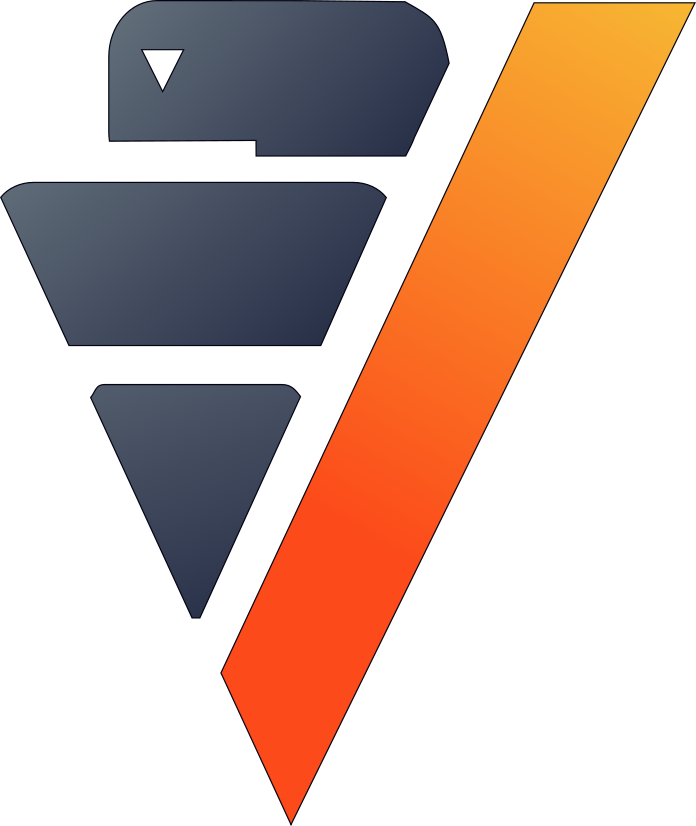

In [13]:
# Identifies the passengers who came alone

single_family = titanic[titanic["family_size"] == 1]
single_family

<b>And Operator (&)</b>

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(6,3)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,AbcVarchar(100),123family_sizeInt,123ln_fareFloat,123xFloat
1,1,0,,male,17.0,0,0,113059,47.1,[null],S,[null],[null],,1,3.85227300102237,1.0
2,1,0,,male,24.0,0,0,PC 17593,79.2,B86,C,[null],[null],,1,4.37197629882038,1.0
3,1,0,,male,23.0,0,0,12749,93.5,B24,S,[null],[null],,1,4.53796143629464,1.0
4,1,0,,male,22.0,0,0,PC 17760,135.6333,[null],C,[null],232,,1,4.90995492057888,1.0
5,1,1,,female,24.0,0,0,PC 17477,69.3,B35,C,9,[null],,1,4.23844490619586,1.0
6,1,1,,female,22.0,0,0,113781,151.55,[null],S,11,[null],,1,5.02091560350381,1.0
7,1,1,,female,19.0,0,0,112053,30.0,B42,S,3,[null],,1,3.40119738166216,0.999999999999906
8,1,1,,female,24.0,0,0,11767,83.1583,C54,C,7,[null],,1,4.42074602026042,1.0
9,1,1,,female,21.0,0,0,13502,77.9583,D9,S,10,[null],,1,4.35617406834722,1.0
10,1,1,,female,16.0,0,0,110152,86.5,B79,S,8,[null],,1,4.46014441393783,1.0

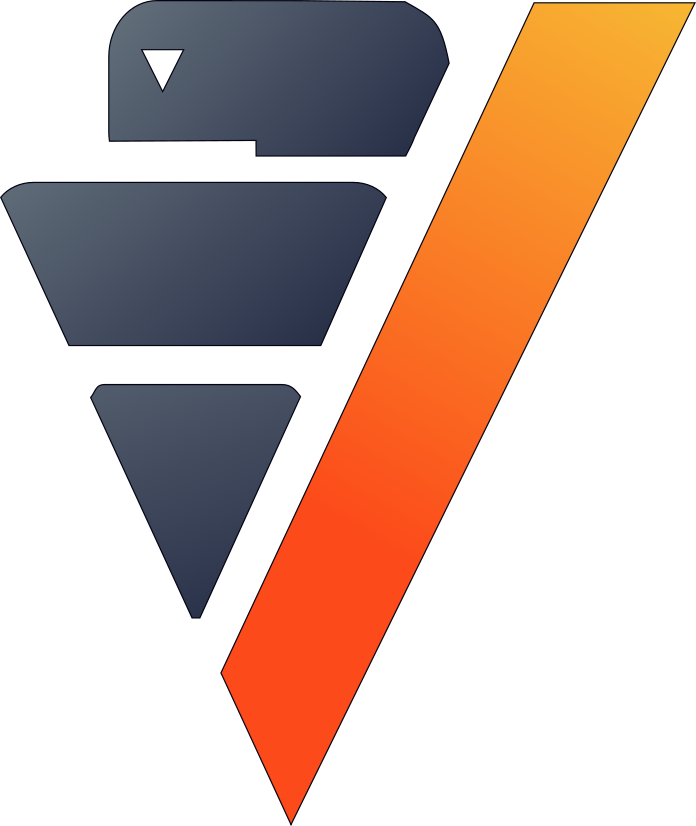

In [6]:
# Identifies the passengers who came alone and 
# who are between 15 and 24 years old...

# ...with comparison operators
single_family[(titanic["age"] >= 15) & (titanic["age"] <= 24)]

<b>Between Operator (_between)</b>

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(6,3)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,AbcVarchar(100),123family_sizeInt,123ln_fareFloat,123xFloat
1,1,0,,male,17.0,0,0,113059,47.1,[null],S,[null],[null],,1,3.85227300102237,1.0
2,1,0,,male,24.0,0,0,PC 17593,79.2,B86,C,[null],[null],,1,4.37197629882038,1.0
3,1,0,,male,23.0,0,0,12749,93.5,B24,S,[null],[null],,1,4.53796143629464,1.0
4,1,0,,male,22.0,0,0,PC 17760,135.6333,[null],C,[null],232,,1,4.90995492057888,1.0
5,1,1,,female,24.0,0,0,PC 17477,69.3,B35,C,9,[null],,1,4.23844490619586,1.0
6,1,1,,female,22.0,0,0,113781,151.55,[null],S,11,[null],,1,5.02091560350381,1.0
7,1,1,,female,19.0,0,0,112053,30.0,B42,S,3,[null],,1,3.40119738166216,0.999999999999906
8,1,1,,female,24.0,0,0,11767,83.1583,C54,C,7,[null],,1,4.42074602026042,1.0
9,1,1,,female,21.0,0,0,13502,77.9583,D9,S,10,[null],,1,4.35617406834722,1.0
10,1,1,,female,16.0,0,0,110152,86.5,B79,S,8,[null],,1,4.46014441393783,1.0

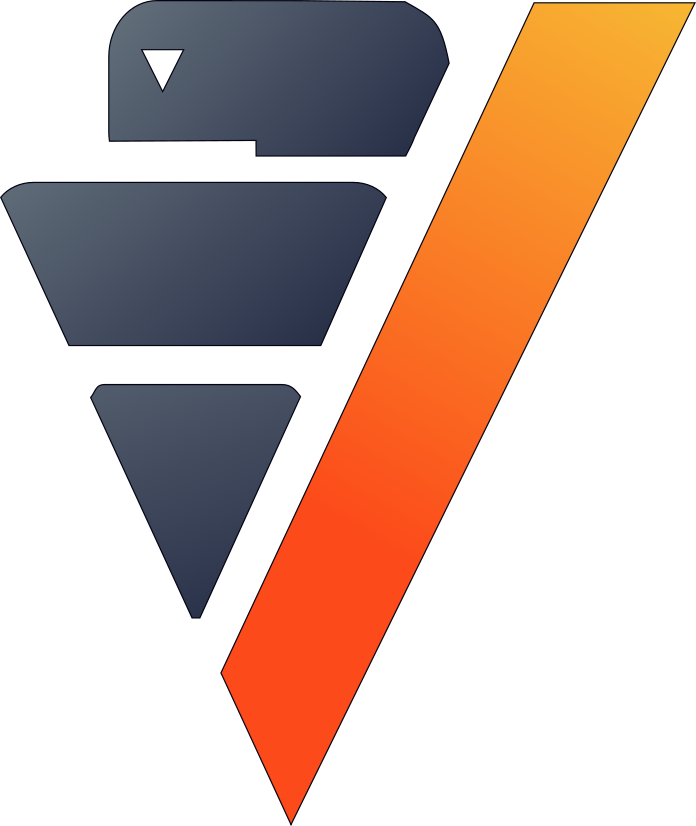

In [7]:
# ...with the 'between' function
single_family[titanic["age"]._between(15, 24)]

<b>In Operator (_in)</b>

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(6,3)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,AbcVarchar(100),123family_sizeInt,123ln_fareFloat,123xFloat
1,1,0,,male,39.0,0,0,112050,0.0,A36,S,[null],[null],,1,-inf,0.0
2,1,0,,male,71.0,0,0,PC 17609,49.5042,[null],C,[null],22,,1,3.90205751446006,1.0
3,1,0,,male,[null],0,0,PC 17318,25.925,[null],S,[null],[null],,1,3.25520775411559,0.999999999994493
4,1,0,,male,36.0,0,0,13050,75.2417,C6,C,A,[null],,1,4.32070559854228,1.0
5,1,0,,male,25.0,0,0,13905,26.0,[null],C,[null],148,,1,3.25809653802148,0.999999999994891
6,1,0,,male,45.0,0,0,113784,35.5,T,S,[null],[null],,1,3.56953269648137,1.0
7,1,0,,male,42.0,0,0,110489,26.55,D22,S,[null],[null],,1,3.27902974768795,0.999999999997052
8,1,0,,male,41.0,0,0,113054,30.5,A21,S,[null],[null],,1,3.41772668361337,0.999999999999943
9,1,0,,male,48.0,0,0,PC 17591,50.4958,B10,C,[null],208,,1,3.92189016450581,1.0
10,1,0,,male,[null],0,0,112379,39.6,[null],C,[null],[null],,1,3.67882911826043,1.0

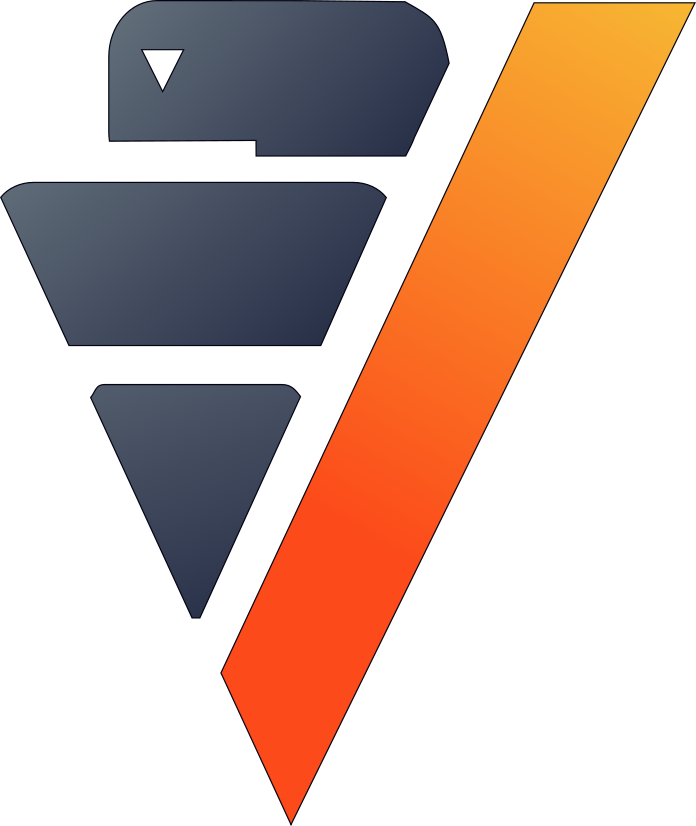

In [8]:
# Identifies the passengers who came alone in 1st and 3rd class...

# ...with the 'in' method
single_family[titanic["pclass"]._in(1, 3)]

<b>Not In Operator (_not_in)</b>

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(6,3)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,AbcVarchar(100),123family_sizeInt
1,1,0,,male,39.0,0,0,112050,0.0,A36,S,[null],[null],,1
2,1,0,,male,71.0,0,0,PC 17609,49.5042,[null],C,[null],22,,1
3,1,0,,male,[null],0,0,PC 17318,25.925,[null],S,[null],[null],,1
4,1,0,,male,36.0,0,0,13050,75.2417,C6,C,A,[null],,1
5,1,0,,male,25.0,0,0,13905,26.0,[null],C,[null],148,,1
6,1,0,,male,45.0,0,0,113784,35.5,T,S,[null],[null],,1
7,1,0,,male,42.0,0,0,110489,26.55,D22,S,[null],[null],,1
8,1,0,,male,41.0,0,0,113054,30.5,A21,S,[null],[null],,1
9,1,0,,male,48.0,0,0,PC 17591,50.4958,B10,C,[null],208,,1
10,1,0,,male,[null],0,0,112379,39.6,[null],C,[null],[null],,1

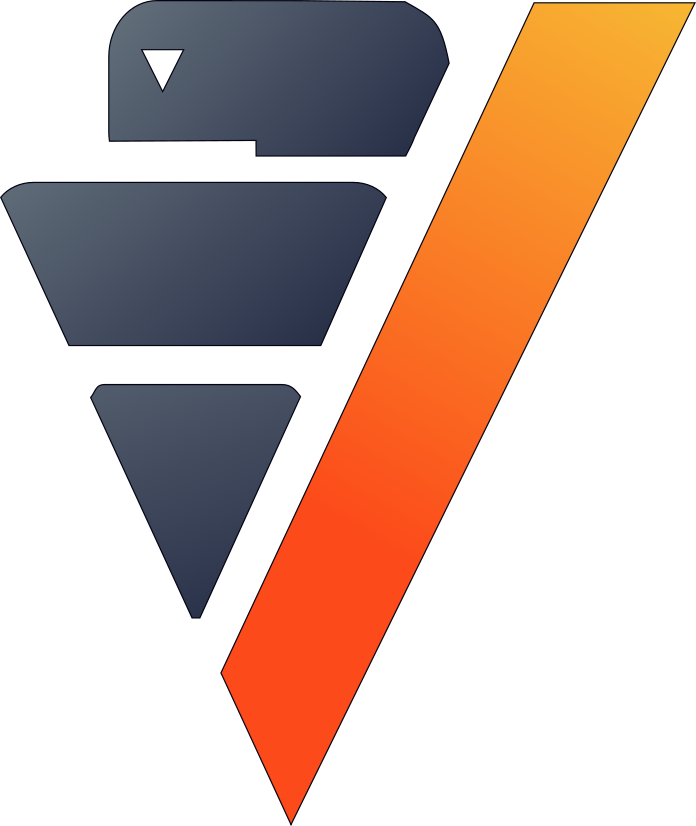

In [14]:
# ...with the 'not_in' method
single_family[titanic["pclass"]._not_in(2)]

<b>Or Operator (|)</b>

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(6,3)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,AbcVarchar(100),123family_sizeInt,123ln_fareFloat,123xFloat
1,1,0,,male,39.0,0,0,112050,0.0,A36,S,[null],[null],,1,-inf,0.0
2,1,0,,male,71.0,0,0,PC 17609,49.5042,[null],C,[null],22,,1,3.90205751446006,1.0
3,1,0,,male,[null],0,0,PC 17318,25.925,[null],S,[null],[null],,1,3.25520775411559,0.999999999994493
4,1,0,,male,36.0,0,0,13050,75.2417,C6,C,A,[null],,1,4.32070559854228,1.0
5,1,0,,male,25.0,0,0,13905,26.0,[null],C,[null],148,,1,3.25809653802148,0.999999999994891
6,1,0,,male,45.0,0,0,113784,35.5,T,S,[null],[null],,1,3.56953269648137,1.0
7,1,0,,male,42.0,0,0,110489,26.55,D22,S,[null],[null],,1,3.27902974768795,0.999999999997052
8,1,0,,male,41.0,0,0,113054,30.5,A21,S,[null],[null],,1,3.41772668361337,0.999999999999943
9,1,0,,male,48.0,0,0,PC 17591,50.4958,B10,C,[null],208,,1,3.92189016450581,1.0
10,1,0,,male,[null],0,0,112379,39.6,[null],C,[null],[null],,1,3.67882911826043,1.0

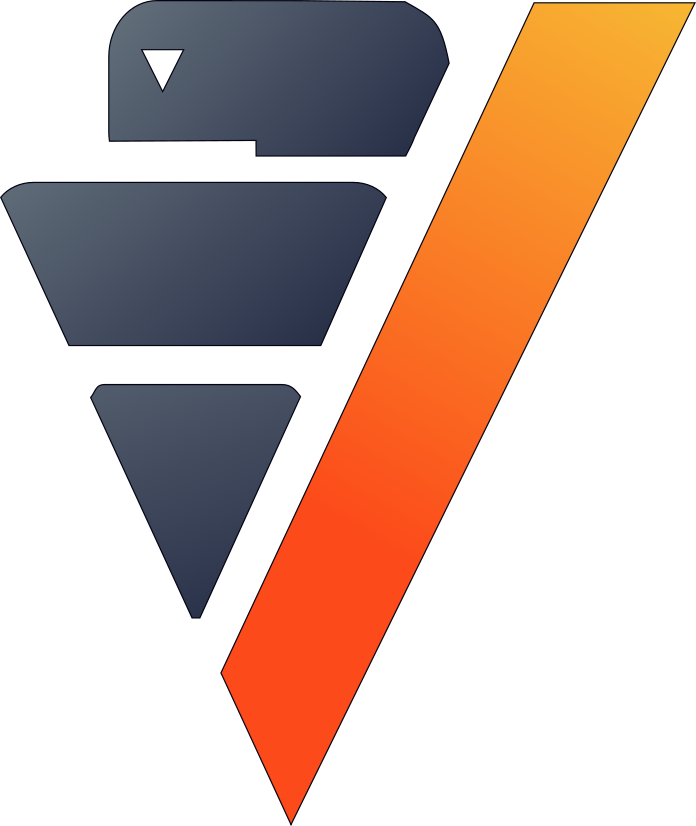

In [12]:
# Or operator
single_family[(titanic["pclass"] == 1) | (titanic["pclass"] == 3)]

<b>Not Equal Operator (!=)</b>

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(6,3)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,AbcVarchar(100),123family_sizeInt,123ln_fareFloat,123xFloat
1,1,0,,male,39.0,0,0,112050,0.0,A36,S,[null],[null],,1,-inf,0.0
2,1,0,,male,71.0,0,0,PC 17609,49.5042,[null],C,[null],22,,1,3.90205751446006,1.0
3,1,0,,male,[null],0,0,PC 17318,25.925,[null],S,[null],[null],,1,3.25520775411559,0.999999999994493
4,1,0,,male,36.0,0,0,13050,75.2417,C6,C,A,[null],,1,4.32070559854228,1.0
5,1,0,,male,25.0,0,0,13905,26.0,[null],C,[null],148,,1,3.25809653802148,0.999999999994891
6,1,0,,male,45.0,0,0,113784,35.5,T,S,[null],[null],,1,3.56953269648137,1.0
7,1,0,,male,42.0,0,0,110489,26.55,D22,S,[null],[null],,1,3.27902974768795,0.999999999997052
8,1,0,,male,41.0,0,0,113054,30.5,A21,S,[null],[null],,1,3.41772668361337,0.999999999999943
9,1,0,,male,48.0,0,0,PC 17591,50.4958,B10,C,[null],208,,1,3.92189016450581,1.0
10,1,0,,male,[null],0,0,112379,39.6,[null],C,[null],[null],,1,3.67882911826043,1.0

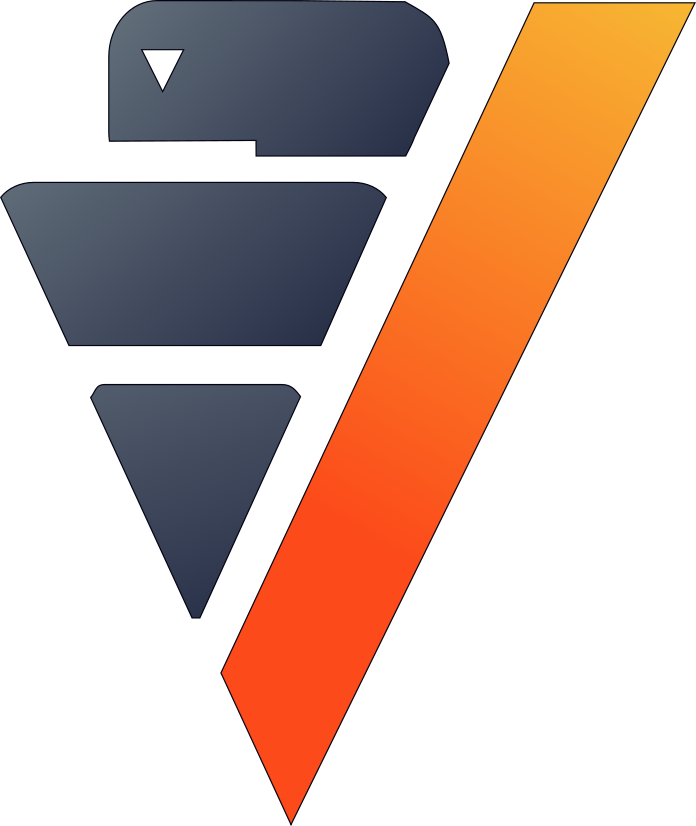

In [13]:
# ...with the not equal operator
single_family[titanic["pclass"] != 2]

## 'Pythonic' Invokation of Vertica Functions

You can easily apply Vertica functions to your vDataFrame. Here, we use Vertica's COALESCE function to impute the 'age' of the passengers in our dataset.

In [14]:
titanic["age"].count()

997.0

In [15]:
import verticapy.stats as st
titanic["age"] = st.coalesce(titanic["age"], titanic["age"].avg())
titanic["age"].count()

1234.0

## Slicing the vDataFrame

You can now slice the vDataFrame with indexing operators.

,123pclassInt,123survivedInt,AbcVarchar(164),AbcsexVarchar(20),"123ageNumeric(16,13)",123sibspInt,123parchInt,AbcticketVarchar(36),"123fareNumeric(10,5)",AbccabinVarchar(30),AbcembarkedVarchar(20),AbcboatVarchar(100),123bodyInt,Abchome.destVarchar(100),123family_sizeInt,123ln_fareFloat,123xFloat
1,1,0,,female,2.0,1,2,113781,151.55,C22 C26,S,[null],[null],"Montreal, PQ / Chesterville, ON",4,5.02091560350381,1.0
2,1,0,,male,30.0,1,2,113781,151.55,C22 C26,S,[null],135,"Montreal, PQ / Chesterville, ON",4,5.02091560350381,1.0
3,1,0,,female,25.0,1,2,113781,151.55,C22 C26,S,[null],[null],"Montreal, PQ / Chesterville, ON",4,5.02091560350381,1.0
4,1,0,,male,39.0,0,0,112050,0.0,A36,S,[null],[null],"Belfast, NI",1,-inf,0.0
5,1,0,,male,71.0,0,0,PC 17609,49.5042,[null],C,[null],22,"Montevideo, Uruguay",1,3.90205751446006,1.0
6,1,0,,male,47.0,1,0,PC 17757,227.525,C62 C64,C,[null],124,"New York, NY",2,5.42726012246342,1.0
7,1,0,,male,30.1524573721163,0,0,PC 17318,25.925,[null],S,[null],[null],"New York, NY",1,3.25520775411559,0.999999999994493
8,1,0,,male,24.0,0,1,PC 17558,247.5208,B58 B60,C,[null],[null],"Montreal, PQ",2,5.51149461888159,1.0
9,1,0,,male,36.0,0,0,13050,75.2417,C6,C,A,[null],"Winnipeg, MN",1,4.32070559854228,1.0
10,1,0,,male,25.0,0,0,13905,26.0,[null],C,[null],148,"San Francisco, CA",1,3.25809653802148,0.999999999994891

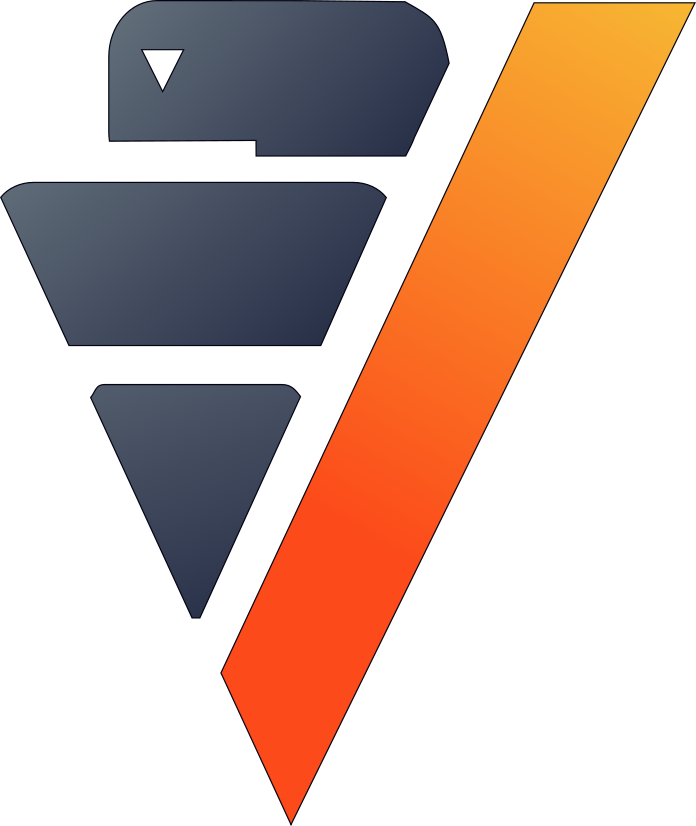

In [16]:
titanic[0:30]

To access a single row, we just have to specify the index.

In [17]:
titanic[0]

[1,
 0,
 'Allison, Miss. Helen Loraine',
 'female',
 2.0,
 1,
 2,
 '113781',
 151.55,
 'C22 C26',
 'S',
 None,
 None,
 'Montreal, PQ / Chesterville, ON',
 4,
 5.02091560350381,
 1.0]